✅ Balanced training distribution: Counter({2: 8331, 1: 8331, 0: 8331})
📊 Model Performance Summary:

                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.823864   0.745431  0.823864  0.775371
1        Decision Tree  0.703734   0.737338  0.703734  0.719743
0  Logistic Regression  0.456575   0.767391  0.456575  0.553033


<Figure size 1000x600 with 0 Axes>

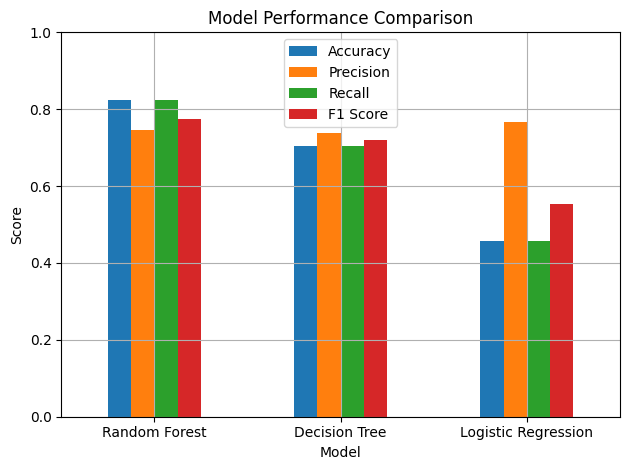

✅ Best model and features saved to ../models/


In [1]:
# Week 5 - Model Evaluation & Export (Balanced)

import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from collections import Counter

# Load and encode
df = pd.read_csv('../data/cleaned.csv')
categorical_cols = [
    'Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
    'Driving_experience', 'Lanes_or_Medians', 'Types_of_Junction',
    'Road_surface_type', 'Light_conditions', 'Weather_conditions',
    'Type_of_collision', 'Vehicle_movement', 'Pedestrian_movement',
    'Cause_of_accident', 'Vehicle_driver_relation'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['Accident_severity'])
y = df_encoded['Accident_severity']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply class balancing
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

print(f"✅ Balanced training distribution: {Counter(y_train_bal)}")

# Train all models
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_bal, y_train_bal)
lr_preds = lr_model.predict(X_test)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_bal, y_train_bal)
dt_preds = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)
rf_preds = rf_model.predict(X_test)

# Evaluate
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1 Score': f1_score(y_true, y_pred, average='weighted')
    }

results_df = pd.DataFrame([
    get_metrics('Logistic Regression', y_test, lr_preds),
    get_metrics('Decision Tree', y_test, dt_preds),
    get_metrics('Random Forest', y_test, rf_preds)
]).sort_values(by='F1 Score', ascending=False)

print("📊 Model Performance Summary:\n")
print(results_df)

# Plot
plt.figure(figsize=(10, 6))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Save best model
best_model = rf_model  # assuming RF is still best
model_dir = os.path.join(os.pardir, 'models')
os.makedirs(model_dir, exist_ok=True)
joblib.dump(best_model, os.path.join(model_dir, 'random_forest_model.pkl'))
joblib.dump(X.columns.tolist(), os.path.join(model_dir, 'feature_columns.pkl'))

print("✅ Best model and features saved to ../models/")